# 🎬 Indian Movies Recommendation System

<div style="background-color: #FF6B6B; color: white; padding: 20px; border-radius: 10px; text-align: center;">
<h2>Building Content-Based and Collaborative Filtering Systems</h2>
<p>A comprehensive guide to movie recommendations using real Indian cinema data</p>
</div>

## 📚 Table of Contents
1. **Data Loading and Exploration**
2. **Content-Based Filtering**
3. **User-User Collaborative Filtering**
4. **Item-Item Collaborative Filtering**
5. **Evaluation Metrics**
6. **Hybrid Approach**
7. **Conclusions and Business Applications**

---

## 🎯 Learning Objectives

By the end of this notebook, you will:
- ✅ Understand how recommendation systems work
- ✅ Implement content-based filtering using movie features
- ✅ Build user-user collaborative filtering
- ✅ Create item-item collaborative filtering
- ✅ Evaluate recommendation quality
- ✅ Apply these techniques to real Indian movie data

---

## 📦 1. Setup and Data Loading

First, let's install required packages and load our Indian movies dataset.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# For Colab users - mount drive if needed
try:
    from google.colab import drive
    print("🎬 Running in Google Colab environment")
except:
    print("💻 Running in local environment")

🎬 Running in Google Colab environment


In [2]:
# Load the Indian movies dataset
# Note: Update these paths based on where you upload the files in Colab

try:
    # Load movies data
    movies_df = pd.read_csv('movies.csv')
    print("✅ Movies data loaded successfully!")

    # Load ratings data with lines=True for JSONL format
    ratings_df_raw = pd.read_json('ratings.json', lines=True)
    print("✅ Raw ratings data loaded successfully!")

    # Transform nested ratings into proper format
    ratings_list = []
    for _, row in ratings_df_raw.iterrows():
        user_id = row['_id']
        if 'rated' in row and isinstance(row['rated'], dict):
            for movie_id, rating_value in row['rated'].items():
                if movie_id != 'submit' and isinstance(rating_value, list) and len(rating_value) > 0:
                    try:
                        rating = float(rating_value[0])
                        # Convert -1,0,1 ratings to 1-5 scale
                        if rating == -1:
                            rating = 1
                        elif rating == 0:
                            rating = 3
                        elif rating == 1:
                            rating = 5
                        ratings_list.append({
                            'userId': user_id,
                            'movieId': movie_id,
                            'rating': rating
                        })
                    except:
                        pass

    ratings_df = pd.DataFrame(ratings_list)
    print("✅ Ratings data transformed successfully!")

    # Load users data
    users_df = pd.read_csv('users.csv')
    print("✅ Users data loaded successfully!")

except FileNotFoundError:
    print("❌ Error: Please upload the data files to Colab or update the file paths")
    print("Required files: movies.csv, ratings.json, users.csv")

✅ Movies data loaded successfully!
✅ Raw ratings data loaded successfully!
✅ Ratings data transformed successfully!
✅ Users data loaded successfully!


### 📊 Data Exploration

Let's understand our dataset structure and content.

In [3]:
# Explore movies dataset
print("🎬 MOVIES DATASET")
print("=" * 50)
print(f"Shape: {movies_df.shape}")
print(f"\nColumns: {list(movies_df.columns)}")
print("\nFirst 3 movies:")
movies_df.head(3)

🎬 MOVIES DATASET
Shape: (2850, 10)

Columns: ['movie_id', 'description', 'language', 'released', 'rating', 'writer', 'director', 'cast', 'genre', 'name']

First 3 movies:


,movie_id,description,language,released,rating,writer,director,cast,genre,name
0,tt5286444,"Neerja is the story of the courageous Neerja Bhanot, who sacrificed her life while protecting th...","[ ""Hindi"" ]",2016-02-19T00:00:00.000Z,7.9,"[ ""Saiwyn Quadras"", ""Sanyukta Shaikh Chawla"" ]","[ ""Ram Madhvani"" ]","[ ""Sonam Kapoor"", ""Shabana Azmi"", ""Yogendra Tikku"", ""Abrar Zahoor"", ""Jim Sarbh"", ""Ali Baldiwala""...","[ ""Biography"", ""Drama"", ""Thriller"" ]",Neerja
1,tt4434004,A story that revolves around drug abuse in the affluent north Indian State of Punjab and how the...,"[ ""Hindi"", ""Panjabi"" ]",2016-06-17T00:00:00.000Z,7.9,"[ ""Sudip Sharma"", ""Abhishek Chaubey"" ]","[ ""Abhishek Chaubey"" ]","[ ""Alia Bhatt"", ""Shahid Kapoor"", ""Diljit Dosanjh"", ""Kareena Kapoor"", ""Taran Bajaj"", ""Mansi Jhing...","[ ""Crime"", ""Drama"", ""Thriller"" ]",Udta Punjab
2,tt0248126,"Yashvardhan Raichand lives a very wealthy lifestyle along with his wife, Nandini, and two sons, ...","[ ""Hindi"", ""English"", ""Urdu"" ]",2001-12-14T00:00:00.000Z,7.5,"[ ""Karan Johar"", ""Sheena Parikh"" ]","[ ""Karan Johar"" ]","[ ""Amitabh Bachchan"", ""Jaya Bhaduri"", ""Shah Rukh Khan"", ""Kajol"", ""Hrithik Roshan"", ""Kareena Kapo...","[ ""Drama"", ""Musical"", ""Romance"" ]",Kabhi Khushi Kabhie Gham...


In [4]:
# Explore ratings dataset
print("⭐ RATINGS DATASET")
print("=" * 50)
print(f"Shape: {ratings_df.shape}")
print(f"\nColumns: {list(ratings_df.columns)}")
print("\nRating statistics:")
print(ratings_df['rating'].describe())
print("\nFirst 5 ratings:")
ratings_df.head()

⭐ RATINGS DATASET
Shape: (20652, 3)

Columns: ['userId', 'movieId', 'rating']

Rating statistics:
count    20652.000000
mean         3.553845
std          1.290447
min          1.000000
25%          3.000000
50%          3.000000
75%          5.000000
max          5.000000
Name: rating, dtype: float64

First 5 ratings:


,userId,movieId,rating
0,11megha89,tt0104561,5
1,11megha89,tt0323013,5
2,11megha89,tt2213054,3
3,11megha89,tt1447508,3
4,11megha89,tt4505006,3


In [5]:
# Explore users dataset
print("👤 USERS DATASET")
print("=" * 50)
print(f"Shape: {users_df.shape}")
print(f"\nColumns: {list(users_df.columns)}")
print("\nUser demographics:")
if 'job' in users_df.columns:
    print("\nJob distribution:")
    print(users_df['job'].value_counts().head())
if 'state' in users_df.columns:
    print("\nState distribution:")
    print(users_df['state'].value_counts().head())
users_df.head()

👤 USERS DATASET
Shape: (924, 6)

Columns: ['_id', 'languages', 'job', 'state', 'dob', 'gender']

User demographics:

Job distribution:
job
Student          575
Service          198
Self-employed     74
Others            65
Retired           11
Name: count, dtype: int64

State distribution:
state
Delhi             637
Andhra Pradesh     65
Uttar Pradesh      63
Haryana            30
Maharashtra        23
Name: count, dtype: int64


,_id,languages,job,state,dob,gender
0,11megha89,"[ ""Hindi"" ]",Student,Haryana,18-04-1989,Female
1,2ez4nimzi,"[ ""Hindi"" ]",Student,Delhi,16-06-2000,Male
2,9953547227,"[ ""Hindi"" ]",Student,Delhi,06-09-1998,Male
3,9958221803,"[ ""Hindi"" ]",Student,Delhi,09-09-1996,Male
4,ABCDEFGHI JKLM,"[ ""Hindi"" ]",Service,Delhi,26-01-1960,Male


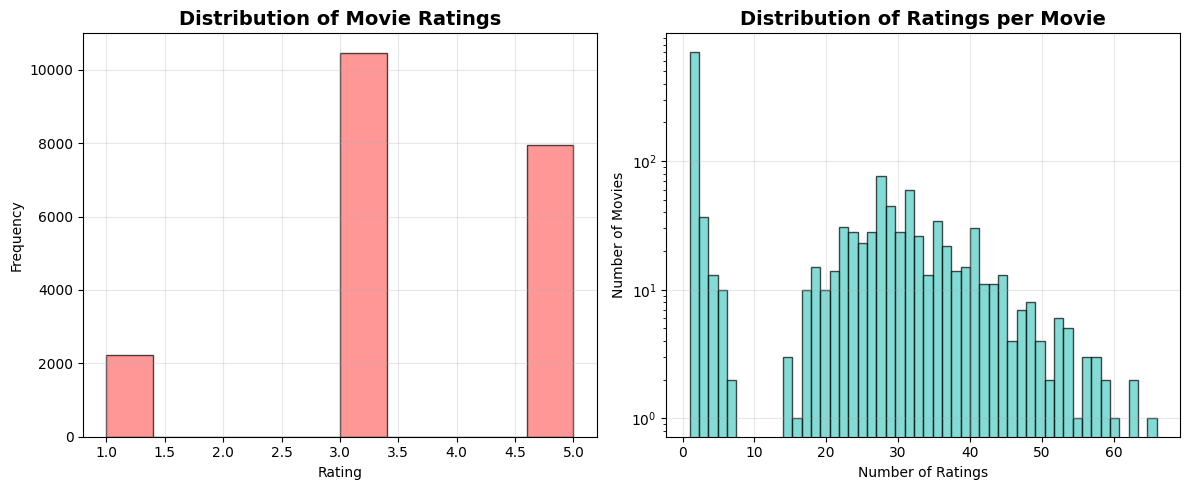

In [6]:
# Visualize rating distribution
plt.figure(figsize=(12, 5))

# Plot 1: Rating distribution
plt.subplot(1, 2, 1)
ratings_df['rating'].hist(bins=10, edgecolor='black', alpha=0.7, color='#FF6B6B')
plt.title('Distribution of Movie Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# Plot 2: Number of ratings per movie
plt.subplot(1, 2, 2)
ratings_per_movie = ratings_df.groupby('movieId').size()
plt.hist(ratings_per_movie, bins=50, edgecolor='black', alpha=0.7, color='#4ECDC4')
plt.title('Distribution of Ratings per Movie', fontsize=14, fontweight='bold')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Movies')
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🎭 2. Content-Based Filtering

Content-based filtering recommends movies based on their features (genre, actors, directors, etc.). We'll use movie metadata to find similar movies.

### How it works:
1. Extract features from movie content (genres, descriptions)
2. Calculate similarity between movies
3. Recommend movies similar to what user liked

In [7]:
# Prepare movie features for content-based filtering
# Let's check what features we have available
print("Available movie features:")
for col in movies_df.columns:
    print(f"- {col}: {movies_df[col].dtype}")
    if movies_df[col].dtype == 'object' and col != 'movie_id':
        print(f"  Sample: {str(movies_df[col].iloc[0])[:100]}...")
    print()

Available movie features:
- movie_id: object

- description: object
  Sample: Neerja is the story of the courageous Neerja Bhanot, who sacrificed her life while protecting the li...

- language: object
  Sample: [ "Hindi" ]...

- released: object
  Sample: 2016-02-19T00:00:00.000Z...

- rating: float64

- writer: object
  Sample: [ "Saiwyn Quadras", "Sanyukta Shaikh Chawla" ]...

- director: object
  Sample: [ "Ram Madhvani" ]...

- cast: object
  Sample: [ "Sonam Kapoor", "Shabana Azmi", "Yogendra Tikku", "Abrar Zahoor", "Jim Sarbh", "Ali Baldiwala", "V...

- genre: object
  Sample: [ "Biography", "Drama", "Thriller" ]...

- name: object
  Sample: Neerja...



In [8]:
# Create a combined feature string for each movie
# This will depend on available columns in your dataset

# Handle missing values
movies_df = movies_df.fillna('')

# Create movieId column to match ratings data
movies_df['movieId'] = movies_df['movie_id']

# Clean the data - remove brackets and quotes from lists
def clean_list_string(s):
    if isinstance(s, str):
        # Remove brackets and quotes, convert to space-separated string
        s = s.replace('[', '').replace(']', '').replace('"', '').replace("'", '')
        return s.strip()
    return str(s)

# Create a feature string combining available text features
movies_df['combined_features'] = ''

# Add movie name
if 'name' in movies_df.columns:
    movies_df['combined_features'] += movies_df['name'].astype(str) + ' '

# Add genre
if 'genre' in movies_df.columns:
    movies_df['combined_features'] += movies_df['genre'].apply(clean_list_string) + ' '

# Add cast
if 'cast' in movies_df.columns:
    movies_df['combined_features'] += movies_df['cast'].apply(clean_list_string) + ' '

# Add director
if 'director' in movies_df.columns:
    movies_df['combined_features'] += movies_df['director'].apply(clean_list_string) + ' '

# Add description
if 'description' in movies_df.columns:
    movies_df['combined_features'] += movies_df['description'].astype(str)

# Clean up the combined features
movies_df['combined_features'] = movies_df['combined_features'].str.strip()

print("Sample combined features:")
for i in range(min(3, len(movies_df))):
    print(f"\nMovie {i+1}: {movies_df['name'].iloc[i]}")
    print(f"Features: {movies_df['combined_features'].iloc[i][:200]}...")

Sample combined features:

Movie 1: Neerja
Features: Neerja Biography, Drama, Thriller Sonam Kapoor, Shabana Azmi, Yogendra Tikku, Abrar Zahoor, Jim Sarbh, Ali Baldiwala, Vikrant Singta, Kirti Adarkar, Parth Akerkar, Hayder Ali, Arjun Aneja, Bobby Arora...

Movie 2: Udta Punjab
Features: Udta Punjab Crime, Drama, Thriller Alia Bhatt, Shahid Kapoor, Diljit Dosanjh, Kareena Kapoor, Taran Bajaj, Mansi Jhingran, Satish Kaushik, Suhail Nayyar, Rajesh Kumar Sharma, Harpreet Singh, Prabhjyot...

Movie 3: Kabhi Khushi Kabhie Gham...
Features: Kabhi Khushi Kabhie Gham... Drama, Musical, Romance Amitabh Bachchan, Jaya Bhaduri, Shah Rukh Khan, Kajol, Hrithik Roshan, Kareena Kapoor, Rani Mukerji, Farida Jalal, Alok Nath, Johnny Lever, Himani S...


In [9]:
# Create TF-IDF matrix for content similarity
print("🔤 Creating TF-IDF matrix for content-based filtering...")

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    stop_words='english',


)

# Fit and transform the combined features
tfidf_matrix = tfidf.fit_transform(movies_df['combined_features'])

print(f"✅ TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Number of movies: {tfidf_matrix.shape[0]}")
print(f"Number of features: {tfidf_matrix.shape[1]}")

🔤 Creating TF-IDF matrix for content-based filtering...
✅ TF-IDF matrix shape: (2850, 19392)
Number of movies: 2850
Number of features: 19392


In [10]:
# Calculate cosine similarity between movies
print("📐 Calculating cosine similarity between movies...")

# Compute cosine similarity matrix
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(f"✅ Similarity matrix shape: {cosine_sim.shape}")
print(f"\nSample similarities for first movie:")
print(f"Min similarity: {cosine_sim[0].min():.3f}")
print(f"Max similarity: {cosine_sim[0].max():.3f}")
print(f"Mean similarity: {cosine_sim[0].mean():.3f}")

📐 Calculating cosine similarity between movies...
✅ Similarity matrix shape: (2850, 2850)

Sample similarities for first movie:
Min similarity: 0.000
Max similarity: 1.000
Mean similarity: 0.006


In [11]:
def get_content_based_recommendations(movie_title, movies_df, cosine_sim, n_recommendations=10):
    """
    Get content-based movie recommendations

    Parameters:
    -----------
    movie_title : str
        Title of the movie to base recommendations on
    movies_df : DataFrame
        Movies dataframe
    cosine_sim : array
        Cosine similarity matrix
    n_recommendations : int
        Number of recommendations to return

    Returns:
    --------
    DataFrame with recommended movies
    """
    try:
        # Get movie index
        idx = movies_df[movies_df['name'].str.contains(movie_title, case=False)].index[0]

        # Get similarity scores for all movies with this movie
        sim_scores = list(enumerate(cosine_sim[idx]))

        # Sort movies by similarity score
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

        # Get indices of most similar movies (excluding the movie itself)
        movie_indices = [i[0] for i in sim_scores[1:n_recommendations+1]]

        # Return the top similar movies
        recommendations = movies_df.iloc[movie_indices][['movieId', 'name', 'genre']].copy()
        recommendations['similarity_score'] = [score[1] for score in sim_scores[1:n_recommendations+1]]

        return recommendations

    except IndexError:
        print(f"❌ Movie '{movie_title}' not found in database")
        return pd.DataFrame()

In [12]:
# Test content-based recommendations
print("🎬 CONTENT-BASED RECOMMENDATIONS DEMO")
print("=" * 50)

# Pick a popular movie (adjust based on your dataset)
test_movie = movies_df['name'].iloc[0]  # Use first movie as example
print(f"\n🎯 Finding movies similar to: '{test_movie}'")

recommendations = get_content_based_recommendations(test_movie, movies_df, cosine_sim)
print("\n📋 Top 10 Recommendations:")
recommendations

🎬 CONTENT-BASED RECOMMENDATIONS DEMO

🎯 Finding movies similar to: 'Neerja'

📋 Top 10 Recommendations:


,movieId,name,genre,similarity_score
96,tt5805252,Budhia Singh: Born to Run,"[ ""Biography"", ""Drama"", ""Sport"" ]",0.079517
107,tt0347332,Khakee,"[ ""Action"", ""Adventure"", ""Drama"" ]",0.059487
1957,tt3954068,Enakkul Oru Devathai,"[ ""Family"" ]",0.057065
391,tt0077783,Junoon,"[ ""Drama"" ]",0.056980
324,tt5513098,Autohead,"[ ""Crime"", ""Drama"" ]",0.056034
494,tt0293589,Shaheed,"[ ""Biography"", ""Drama"", ""History"" ]",0.055881
1270,tt1608777,"LSD: Love, Sex Aur Dhokha","[ ""Comedy"", ""Crime"", ""Drama"" ]",0.054789
629,tt1961143,...EBONG KANNA,"[ ""Drama"", ""Western"" ]",0.050782
583,tt0350005,Pyaar Ki Jeet,"[ ""Comedy"", ""Drama"", ""Musical"" ]",0.050742
2625,tt2358592,Lucia,"[ ""Drama"", ""Romance"", ""Sci-Fi"" ]",0.049544


## 👥 3. User-User Collaborative Filtering

User-User collaborative filtering finds users with similar preferences and recommends movies they liked.

### How it works:
1. Find users with similar rating patterns
2. Identify movies they rated highly that target user hasn't seen
3. Recommend those movies

In [13]:
# Create user-item rating matrix
print("📊 Creating user-item rating matrix...")

# Pivot ratings to create matrix
user_item_matrix = ratings_df.pivot_table(
    index='userId',
    columns='movieId',
    values='rating',
    fill_value=0
)

print(f"✅ User-Item matrix shape: {user_item_matrix.shape}")
print(f"Number of users: {user_item_matrix.shape[0]}")
print(f"Number of movies: {user_item_matrix.shape[1]}")
print(f"Sparsity: {(user_item_matrix == 0).sum().sum() / (user_item_matrix.shape[0] * user_item_matrix.shape[1]) * 100:.2f}%")

📊 Creating user-item rating matrix...
✅ User-Item matrix shape: (757, 1382)
Number of users: 757
Number of movies: 1382
Sparsity: 98.03%


In [14]:
user_item_matrix

movieId         tt0028626  tt0031829  tt0032836  tt0036077  tt0040067  \
userId                                                                  
11megha89             0.0        0.0        0.0        0.0        0.0   
9953547227            0.0        0.0        0.0        0.0        0.0   
ABCDEFGHI JKLM        0.0        0.0        0.0        0.0        0.0   
ANAND                 0.0        0.0        0.0        0.0        0.0   
Aakanksha             0.0        0.0        0.0        0.0        0.0   
...                   ...        ...        ...        ...        ...   
yagami_kunal          0.0        0.0        0.0        0.0        0.0   
yajur16121            0.0        0.0        0.0        0.0        0.0   
yomojet               0.0        0.0        0.0        0.0        0.0   
yusuf                 0.0        0.0        0.0        0.0        0.0   
zainab                0.0        0.0        0.0        0.0        0.0   

movieId         tt0041123  tt0042329  tt0043307  tt0043908  tt0044360  \
userId                                                                  
11megha89             0.0        0.0        0.0        0.0        0.0   
9953547227            0.0        0.0        0.0        0.0        0.0   
ABCDEFGHI JKLM        0.0        0.0        0.0        0.0        0.0   
ANAND                 0.0        0.0        0.0        0.0        0.0   
Aakanksha             0.0        0.0        0.0        0.0        0.0   
...                   ...        ...        ...        ...        ...   
yagami_kunal          0.0        0.0        0.0        0.0        0.0   
yajur16121            0.0        0.0        0.0        0.0        0.0   
yomojet               0.0        0.0        0.0        0.0        0.0   
yusuf                 0.0        0.0        0.0        0.0        0.0   
zainab                0.0        0.0        0.0        0.0        0.0   

movieId         tt0045506  tt0045528  tt0045693  tt0046155  tt0046176  \
userId                                                                  
11megha89             0.0        0.0        0.0        0.0        0.0   
9953547227            0.0        0.0        0.0        0.0        0.0   
ABCDEFGHI JKLM        0.0        0.0        0.0        0.0        0.0   
ANAND                 0.0        0.0        0.0        0.0        0.0   
Aakanksha             0.0        0.0        0.0        3.0        0.0   
...                   ...        ...        ...        ...        ...   
yagami_kunal          0.0        0.0        0.0        0.0        0.0   
yajur16121            0.0        0.0        0.0        0.0        0.0   
yomojet               5.0        0.0        0.0        0.0        0.0   
yusuf                 0.0        0.0        0.0        0.0        0.0   
zainab                0.0        0.0        0.0        0.0        0.0   

movieId         tt0046304  tt0047990  tt0048537  tt0048987  tt0049041  \
userId                                                                  
11megha89             0.0        0.0        0.0        0.0        0.0   
9953547227            0.0        0.0        0.0        0.0        0.0   
ABCDEFGHI JKLM        0.0        0.0        0.0        0.0        0.0   
ANAND                 0.0        0.0        0.0        3.0        0.0   
Aakanksha             0.0        5.0        0.0        0.0        0.0   
...                   ...        ...        ...        ...        ...   
yagami_kunal          0.0        0.0        0.0        0.0        0.0   
yajur16121            0.0        0.0        0.0        0.0        0.0   
yomojet               0.0        0.0        0.0        0.0        0.0   
yusuf                 0.0        0.0        0.0        0.0        0.0   
zainab                0.0        0.0        0.0        0.0        0.0   

movieId         tt0049072  tt0049378  tt0049393  tt0049643  tt0049752  \
userId                                                                  
11megha89             0.0        0.0        0.0       

In [15]:
# Calculate user-user similarity using cosine similarity
print("👥 Calculating user-user similarity...")

# For computational efficiency, we'll work with a subset if dataset is large
if user_item_matrix.shape[0] > 1000:
    print("⚠️ Large dataset detected. Using subset for demonstration...")
    sample_users = np.random.choice(user_item_matrix.index, 500, replace=False)
    user_item_subset = user_item_matrix.loc[sample_users]
else:
    user_item_subset = user_item_matrix

# Calculate cosine similarity between users
user_similarity = cosine_similarity(user_item_subset)
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_subset.index,
    columns=user_item_subset.index
)

print(f"✅ User similarity matrix shape: {user_similarity_df.shape}")

👥 Calculating user-user similarity...
✅ User similarity matrix shape: (757, 757)


In [47]:
user_similarity_df

userId,11megha89,9953547227,ABCDEFGHI JKLM,ANAND,Aakanksha,Aakash,Aakash22,Aashisha,Aayushi,Abhijeet Mishra,Abhimanyu Tanwar,Abhishek,Abhishek Gupta,Aditipathak,Aditya,Afsha shah,Ahmad,Ajay,Ajay12,Ajay1998,Akanksha,Akanksha Mishra,Akansha,Akash28,Akash869,Akshat,Alka,AlkaGupta,Alok Singh,Amandeep,Amitjain,Anil Marwah,Anil kumar,Anita Goel,AnjaliUjjainia,Anju,Ankur Rastogi,Ankur Sharma,Anmol18,Anshul,Anshuman Suri,Anubhav,Anudita,Anuprriya,Anusha Raj,Anvit,Any,Apoorv,Apurupa,Arashdeep Kaur,Archana,Arjun13022,Arnav Kumar,Arun,Arun Garg,Arun Kumar Gupta,Ashish07,Ashish16021,Ashish_16,Ashok,Ashok Kumar,Ashutosh Brahma,Astitv,Avadh,Avdesh Kumar,Avinash,Avneet,Aysha,Ayush Raj Mehrotra,Bharat70,Bhaskarverma725,BhatiaCo,Bhawani,Bhuwan Pathak,Bijla_Rana,BlueO,Ch1ck3n65,Champa72,Chanchal,Chanderkala,Cheerag1,Cheerag7,Cheffy,Chita Chidambaram,Cloak98,CoolSatyam,Cosmopal,D.Saksham,D1,Daljeet,Deadpool2,Dee,Deeksha,Deepak,Deepak _ca2004,Deepti,Deepu singh,Devi Prasad jena,Dewangee,Dhruv Bhagat,Diadem98,Dimpi,Dimple,Divya,Divya95,Dush,Ekta,Erised98,Faiz,Fazilath,Feeroz Ahmed,Gaurav sharma,Gautam,Geeta,Ginnik,Gita,Gitasharma,Gotuhell,Gunkirat,Guruji_Deadpool,Harjeet,Harsh,Harshit panwar,Hasan Jawaid Khan,Haseena,Hedwig30,Himanshi,Himanshu Sharma,Hina,Hina,Holmesfan,Ishaan Bassi,JKLM ABCDEFGHI,Jasbir panwar,KIRA,Kanika,Kanupriya Dang,Kapeesh,Karish08,Karunakar Singh,Kasturi,Khan,Khushi,Kiran,Krishna,Kunal,Kundan,LATA007,Lakshya,Lalitha,Lekh Raj,Lokender Singh,LovedeepChhokra,M H Akhtar,Madan,MaddyThakker,Madhav,Madhav Goel,Madhav Thakker,MadhurV9784,Mahi,Mahima Verma,MalikMishra,Manas,Manish,Manmeet,Manveer__Rana,Meenakshi Garg,Megha,Mkverma,Mona,Mr.CA005,MrCruiser,Mrakash,Mudit goel,Mugen,Mukesh_Rawat,Mukki_Rana,Munish,NAKUL,NSB64,NSB64_,Nakul,Nakul lawaria,Namrata13065,Nandini,Naresh,NareshJain,Naveenchd,Nawazish,Nbhatia,Neera,Neeti Arora,Neetu,Neetu Singh,Neha Sharma,Nepun Suneja,Nilesh,Nishad Bhelekar,Nitin Kumar,Nitin13070,Om Prakash,Pkaksha,Poonamsaini,Pradeep Sharma,Prakashb,Pramod_Agg,Pramodh,PrateekSingh,Preeti,PremL,Prince patel,Priya15073,Priysha20,Protichi,REVERB283,Raghav,Raghav Verma,Raghav1,Raghavv,Rahul,Rahul Bansal,Raj Kamal,Raj Kumar,Rajesh,Rajesh Bhagat,RajeshVerma,Rajni Gupta,Rakesh123,Ralph,Ram,Ramanathan,Rashi.prakash8,Ratan,Redusa,Richa,Richa Goel,RichaGoswami,RichaS7,RishabhGoswami,Rishi,Ritu,Ritvik13078,Rohit,Roshan,Rosy,Rsc98,Rsh2ada,S P,S P Sharma,SSSharma,SSingh1402,Sagar Verma,Sahil Vaid,Sai Sabitha,SaiKiran,Saksham,Saksham Gupta,Sameer Khan,Sandeeps,Sangita_1001,Sanjay,Sanjay Kumar,Sanjiv,SankaLp,Santosh,Sarang,Sarthak Aditya,Satish,Satyam choudhary,Satyam007,Saurabh,Sautan Sharma,Savita,Savitaverma,Shahab,Shaloo,Shanky,Sharmistha Gupta,Shashi,Sheeba Naqvi,Shilpa,Shinu,Shivani,Shivin,Shivkseth,Shravika,Shreetama,Shreshtha singhal,Shreyas,Shruti,ShubhamGoswami,Shubhra,Shweta,Shweta Rana,Shweta2206,Shyam,Siddhi singhal,Simran,Sm,Snigdha,Sooraj,Sraj,Srattan98,Srishti,Ss2195,Sunil kumar,Sunita,Sunny110051,Surabhi,Suraj,Suraj Prathik Kumar,Swatilekha Majumdar,Sweta_Chhokra,Switi,Taejas,Tanish,The mysterious,Umashankar,Umesh Gupta,Utkarsh,Utkarsh Kohli,Vaibhav Dang,Vanshika gupta,Varshasharma,Vartika,Vatsala Arora,Vedant,Vedant1,Vedant2,Venu,Vijay,Vikas,VikashKumandan,Vipin Goel,Vishal Hooda,Vishal711,VishalS711,VishalSR711,Vishwas,WadeWilson,Yashu,Yatendra,Yogesh,YuvraJ Sharma,Zirgham,Zoha,aakash16215,aakashjoshi,aayush9,abdulkhan,abhi,abhim51,abhimanyu,abhishek13005,abhishek16006,abhishek2309,acckoul,achala.sharma25,achetan40,adarsh_007,adinehria,aditya16008,aditya16127,adityas114,adiv12,afzal ahemad,agarwal_a,agrawalamod,aishwarya,aishwarya14130,ajay1967,ajit,ak.shinde09,akaReddy,akanksha,akif.khan,akshat14132,alpna,aman,amandeep,amar,amit010dalel,ampk349,anandita9988,anant3110,anildhawan,anjali9899,anjaniarnav,ankit sharma,ankushvarma12,anmol89,anoop,anshika,anshul,anshumanprakash123,anubha,anujrawal,anurag,anushka16134,anvitmangal,appu250,aprajita1964,archana,archanag,arp229,arpana,arsh25,arun,arun gaba,arunp,arush

In [17]:
def get_user_based_recommendations(user_id, user_similarity_df, user_item_matrix, n_recommendations=10):
    """
    Get user-based collaborative filtering recommendations

    Parameters:
    -----------
    user_id : int
        Target user ID
    user_similarity_df : DataFrame
        User similarity matrix
    user_item_matrix : DataFrame
        User-item rating matrix
    n_recommendations : int
        Number of recommendations

    Returns:
    --------
    DataFrame with recommended movies
    """
    try:
        # Get similar users
        if user_id not in user_similarity_df.index:
            print(f"❌ User {user_id} not in similarity matrix")
            return pd.DataFrame()

        similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:11]

        # Get movies rated by similar users
        similar_users_ratings = user_item_matrix.loc[similar_users.index]

        # Calculate weighted average of ratings
        weighted_ratings = similar_users_ratings.T.dot(similar_users.values) / similar_users.sum()

        # Remove movies already rated by target user
        user_rated = user_item_matrix.loc[user_id]
        recommendations = weighted_ratings[user_rated == 0]

        # Get top recommendations
        top_recommendations = recommendations.sort_values(ascending=False).head(n_recommendations)

        # Create results dataframe
        results = pd.DataFrame({
            'movieId': top_recommendations.index,
            'predicted_rating': top_recommendations.values
        })

        # Merge with movie information
        results = results.merge(movies_df[['movieId', 'name', 'genre']], on='movieId', how='left')

        return results

    except Exception as e:
        print(f"❌ Error: {e}")
        return pd.DataFrame()

In [18]:
# Test user-based recommendations
print("👥 USER-BASED RECOMMENDATIONS DEMO")
print("=" * 50)

# Pick a random user from our subset
test_user = user_item_subset.index[0]
print(f"\n🎯 Getting recommendations for User {test_user}")

# Show what this user has already rated
user_ratings = ratings_df[ratings_df['userId'] == test_user].merge(
    movies_df[['movieId', 'name']], on='movieId'
).sort_values('rating', ascending=False).head(5)

print("\n📋 User's top-rated movies:")
print(user_ratings[['name', 'rating']])

# Get recommendations
user_recommendations = get_user_based_recommendations(test_user, user_similarity_df, user_item_subset)
print("\n🎬 Recommended movies:")
user_recommendations

👥 USER-BASED RECOMMENDATIONS DEMO

🎯 Getting recommendations for User 11megha89

📋 User's top-rated movies:
                          name  rating
0       Jo Jeeta Wohi Sikandar       5
1                      Lakshya       5
7         Gadar: Ek Prem Katha       5
6                   Veer-Zaara       5
5  Kabhi Khushi Kabhie Gham...       5

🎬 Recommended movies:


,movieId,predicted_rating,name,genre
0,tt0112870,1.962347,Dilwale Dulhania Le Jayenge,"[ ""Comedy"", ""Drama"", ""Musical"" ]"
1,tt0066070,1.517743,Mera Naam Joker,"[ ""Comedy"", ""Drama"" ]"
2,tt0499375,1.050006,Guru,"[ ""Biography"", ""Drama"", ""Musical"" ]"
3,tt0077797,1.047661,Khatta Meetha,"[ ""Comedy"", ""Family"", ""Drama"" ]"
4,tt4434004,0.942436,Udta Punjab,"[ ""Crime"", ""Drama"", ""Thriller"" ]"
5,tt1926313,0.817437,Pyaar Ka Punchnama,"[ ""Comedy"", ""Drama"", ""Romance"" ]"
6,tt0072777,0.797963,Chhoti Si Baat,"[ ""Comedy"", ""Romance"" ]"
7,tt0242519,0.674564,Hera Pheri,"[ ""Comedy"", ""Crime"", ""Thriller"" ]"
8,tt0234225,0.566555,Meet Mere Man Ke,[]
9,tt0050132,0.566555,Apradhi Kaun?,"[ ""Mystery"" ]"


## 🎬 4. Item-Item Collaborative Filtering

Item-Item collaborative filtering finds similar movies based on user rating patterns.

### How it works:
1. Calculate similarity between movies based on user ratings
2. For movies a user liked, find similar movies
3. Recommend those similar movies

In [48]:
user_item_matrix

movieId         tt0028626  tt0031829  tt0032836  tt0036077  tt0040067  \
userId                                                                  
11megha89             0.0        0.0        0.0        0.0        0.0   
9953547227            0.0        0.0        0.0        0.0        0.0   
ABCDEFGHI JKLM        0.0        0.0        0.0        0.0        0.0   
ANAND                 0.0        0.0        0.0        0.0        0.0   
Aakanksha             0.0        0.0        0.0        0.0        0.0   
...                   ...        ...        ...        ...        ...   
yagami_kunal          0.0        0.0        0.0        0.0        0.0   
yajur16121            0.0        0.0        0.0        0.0        0.0   
yomojet               0.0        0.0        0.0        0.0        0.0   
yusuf                 0.0        0.0        0.0        0.0        0.0   
zainab                0.0        0.0        0.0        0.0        0.0   

movieId         tt0041123  tt0042329  tt0043307  tt0043908  tt0044360  \
userId                                                                  
11megha89             0.0        0.0        0.0        0.0        0.0   
9953547227            0.0        0.0        0.0        0.0        0.0   
ABCDEFGHI JKLM        0.0        0.0        0.0        0.0        0.0   
ANAND                 0.0        0.0        0.0        0.0        0.0   
Aakanksha             0.0        0.0        0.0        0.0        0.0   
...                   ...        ...        ...        ...        ...   
yagami_kunal          0.0        0.0        0.0        0.0        0.0   
yajur16121            0.0        0.0        0.0        0.0        0.0   
yomojet               0.0        0.0        0.0        0.0        0.0   
yusuf                 0.0        0.0        0.0        0.0        0.0   
zainab                0.0        0.0        0.0        0.0        0.0   

movieId         tt0045506  tt0045528  tt0045693  tt0046155  tt0046176  \
userId                                                                  
11megha89             0.0        0.0        0.0        0.0        0.0   
9953547227            0.0        0.0        0.0        0.0        0.0   
ABCDEFGHI JKLM        0.0        0.0        0.0        0.0        0.0   
ANAND                 0.0        0.0        0.0        0.0        0.0   
Aakanksha             0.0        0.0        0.0        3.0        0.0   
...                   ...        ...        ...        ...        ...   
yagami_kunal          0.0        0.0        0.0        0.0        0.0   
yajur16121            0.0        0.0        0.0        0.0        0.0   
yomojet               5.0        0.0        0.0        0.0        0.0   
yusuf                 0.0        0.0        0.0        0.0        0.0   
zainab                0.0        0.0        0.0        0.0        0.0   

movieId         tt0046304  tt0047990  tt0048537  tt0048987  tt0049041  \
userId                                                                  
11megha89             0.0        0.0        0.0        0.0        0.0   
9953547227            0.0        0.0        0.0        0.0        0.0   
ABCDEFGHI JKLM        0.0        0.0        0.0        0.0        0.0   
ANAND                 0.0        0.0        0.0        3.0        0.0   
Aakanksha             0.0        5.0        0.0        0.0        0.0   
...                   ...        ...        ...        ...        ...   
yagami_kunal          0.0        0.0        0.0        0.0        0.0   
yajur16121            0.0        0.0        0.0        0.0        0.0   
yomojet               0.0        0.0        0.0        0.0        0.0   
yusuf                 0.0        0.0        0.0        0.0        0.0   
zainab                0.0        0.0        0.0        0.0        0.0   

movieId         tt0049072  tt0049378  tt0049393  tt0049643  tt0049752  \
userId                                                                  
11megha89             0.0        0.0        0.0       

In [19]:
# Calculate item-item similarity
print("🎬 Calculating item-item similarity...")

# Transpose the matrix for item-item similarity
item_user_matrix = user_item_matrix.T

# For efficiency, work with movies that have at least 10 ratings
min_ratings = 10
movie_rating_counts = (item_user_matrix > 0).sum(axis=1)
popular_movies = movie_rating_counts[movie_rating_counts >= min_ratings].index
item_user_subset = item_user_matrix.loc[popular_movies]

print(f"📊 Working with {len(popular_movies)} movies (out of {len(item_user_matrix)}) with >= {min_ratings} ratings")

# Calculate cosine similarity between items
item_similarity = cosine_similarity(item_user_subset)
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_subset.index,
    columns=item_user_subset.index
)

print(f"✅ Item similarity matrix shape: {item_similarity_df.shape}")

🎬 Calculating item-item similarity...
📊 Working with 611 movies (out of 1382) with >= 10 ratings
✅ Item similarity matrix shape: (611, 611)


In [39]:
item_similarity_df

movieId,tt0028626,tt0032836,tt0036077,tt0040067,tt0041123,tt0043307,tt0043908,tt0044360,tt0045506,tt0045693,tt0046155,tt0047990,tt0048537,tt0048987,tt0049041,tt0049072,tt0049378,tt0050132,tt0050322,tt0050665,tt0050758,tt0052217,tt0052560,tt0053791,tt0053985,tt0054059,tt0054737,tt0055444,tt0056052,tt0056436,tt0056806,tt0056998,tt0057332,tt0060306,tt0060444,tt0060659,tt0060689,tt0061072,tt0061073,tt0061378,tt0061753,tt0061963,tt0063404,tt0064086,tt0064244,tt0065764,tt0066070,tt0066758,tt0066763,tt0067403,tt0067421,tt0068217,tt0068257,tt0069671,tt0070498,tt0070530,tt0070947,tt0071083,tt0071145,tt0072064,tt0072777,tt0072783,tt0072860,tt0073034,tt0073391,tt0073458,tt0073627,tt0073707,tt0074730,tt0074858,tt0074926,tt0075143,tt0075669,tt0075747,tt0075860,tt0076696,tt0077451,tt0077783,tt0077797,tt0078418,tt0078724,tt0079221,tt0079386,tt0079590,tt0079938,tt0080322,tt0080435,tt0080982,tt0081968,tt0082162,tt0082314,tt0082796,tt0083570,tt0083575,tt0083578,tt0083790,tt0084667,tt0084840,tt0085138,tt0085178,tt0085743,tt0085776,tt0085896,tt0085913,tt0086230,tt0086597,tt0087417,tt0087736,tt0088031,tt0088986,tt0089413,tt0089599,tt0090812,tt0091256,tt0091598,tt0093578,tt0093603,tt0094979,tt0095936,tt0096028,tt0098999,tt0099043,tt0099652,tt0100002,tt0100095,tt0100401,tt0102636,tt0102701,tt0104561,tt0105271,tt0106333,tt0106655,tt0107166,tt0109117,tt0109206,tt0109424,tt0109555,tt0110076,tt0110222,tt0112553,tt0112870,tt0114234,tt0116630,tt0116763,tt0116950,tt0118751,tt0119720,tt0120456,tt0128985,tt0129370,tt0135399,tt0137361,tt0137459,tt0137958,tt0138994,tt0139065,tt0139157,tt0139876,tt0140370,tt0140399,tt0140784,tt0141441,tt0142385,tt0142431,tt0145851,tt0146266,tt0146335,tt0146791,tt0149753,tt0150417,tt0150433,tt0150683,tt0150992,tt0151156,tt0151511,tt0153549,tt0154026,tt0154565,tt0154942,tt0155408,tt0156058,tt0156098,tt0156160,tt0156256,tt0156290,tt0156444,tt0156581,tt0156690,tt0156782,tt0156903,tt0156930,tt0156995,tt0157125,tt0157316,tt0157339,tt0157460,tt0157518,tt0157572,tt0157845,tt0157882,tt0158074,tt0158212,tt0158314,tt0158481,tt0158579,tt0158914,tt0164538,tt0165795,tt0165972,tt0166008,tt0169102,tt0172684,tt0176313,tt0177490,tt0178186,tt0178392,tt0195002,tt0195231,tt0196069,tt0200087,tt0211126,tt0214082,tt0214704,tt0214841,tt0215515,tt0215517,tt0215902,tt0215911,tt0216019,tt0216067,tt0220757,tt0220832,tt0222012,tt0230141,tt0230622,tt0231348,tt0231520,tt0231645,tt0232050,tt0232066,tt0232155,tt0232960,tt0233330,tt0233635,tt0234070,tt0234211,tt0234225,tt0235094,tt0238936,tt0240200,tt0240879,tt0241753,tt0242519,tt0242839,tt0243447,tt0244585,tt0244776,tt0245830,tt0246809,tt0246913,tt0247291,tt0248126,tt0249358,tt0249795,tt0251067,tt0252316,tt0254247,tt0255289,tt0255713,tt0256406,tt0262714,tt0262866,tt0263993,tt0264415,tt0265902,tt0266757,tt0267363,tt0268167,tt0270321,tt0271827,tt0274353,tt0275489,tt0280398,tt0280465,tt0280968,tt0283005,tt0284137,tt0284456,tt0286576,tt0290326,tt0290632,tt0290820,tt0291376,tt0292490,tt0293385,tt0293589,tt0295294,tt0296574,tt0299078,tt0299108,tt0300575,tt0300980,tt0301231,tt0306434,tt0308158,tt0310865,tt0313495,tt0316268,tt0316407,tt0319165,tt0319736,tt0320100,tt0320792,tt0323013,tt0328810,tt0329393,tt0331261,tt0337578,tt0338472,tt0338490,tt0341455,tt0345177,tt0347304,tt0347332,tt0347779,tt0350005,tt0351714,tt0352314,tt0352457,tt0356982,tt0357782,tt0359750,tt0360399,tt0362038,tt0362067,tt0362696,tt0363994,tt0367110,tt0367214,tt0367495,tt0368444,tt0371636,tt0371735,tt0371974,tt0373790,tt0373856,tt0374117,tt0374342,tt0374887,tt0375066,tt0375611,tt0376127,tt0378647,tt0379370,tt0379375,tt0382383,tt0388389,tt0390657,tt0392835,tt0400234,tt0402014,tt0405266,tt0405508,tt0411469,tt0413984,tt0414713,tt0415144,tt0419992,tt0420332,tt0420517,tt0432047,tt0433416,tt0433425,tt0442610,tt0449994,tt0451919,tt0452878,tt0453729,tt0454314,tt0454876,tt0456144,tt0457655,tt0457802,tt0459293,tt0466460,tt0471571,tt0473367,tt0473567,tt0477857,tt0479751,tt0482800,tt0488414,tt0497611,tt0499375,tt0758438,tt0781434,tt0808357,tt0824316,tt0833533,tt

In [49]:
user_item_matrix

movieId         tt0028626  tt0031829  tt0032836  tt0036077  tt0040067  \
userId                                                                  
11megha89             0.0        0.0        0.0        0.0        0.0   
9953547227            0.0        0.0        0.0        0.0        0.0   
ABCDEFGHI JKLM        0.0        0.0        0.0        0.0        0.0   
ANAND                 0.0        0.0        0.0        0.0        0.0   
Aakanksha             0.0        0.0        0.0        0.0        0.0   
...                   ...        ...        ...        ...        ...   
yagami_kunal          0.0        0.0        0.0        0.0        0.0   
yajur16121            0.0        0.0        0.0        0.0        0.0   
yomojet               0.0        0.0        0.0        0.0        0.0   
yusuf                 0.0        0.0        0.0        0.0        0.0   
zainab                0.0        0.0        0.0        0.0        0.0   

movieId         tt0041123  tt0042329  tt0043307  tt0043908  tt0044360  \
userId                                                                  
11megha89             0.0        0.0        0.0        0.0        0.0   
9953547227            0.0        0.0        0.0        0.0        0.0   
ABCDEFGHI JKLM        0.0        0.0        0.0        0.0        0.0   
ANAND                 0.0        0.0        0.0        0.0        0.0   
Aakanksha             0.0        0.0        0.0        0.0        0.0   
...                   ...        ...        ...        ...        ...   
yagami_kunal          0.0        0.0        0.0        0.0        0.0   
yajur16121            0.0        0.0        0.0        0.0        0.0   
yomojet               0.0        0.0        0.0        0.0        0.0   
yusuf                 0.0        0.0        0.0        0.0        0.0   
zainab                0.0        0.0        0.0        0.0        0.0   

movieId         tt0045506  tt0045528  tt0045693  tt0046155  tt0046176  \
userId                                                                  
11megha89             0.0        0.0        0.0        0.0        0.0   
9953547227            0.0        0.0        0.0        0.0        0.0   
ABCDEFGHI JKLM        0.0        0.0        0.0        0.0        0.0   
ANAND                 0.0        0.0        0.0        0.0        0.0   
Aakanksha             0.0        0.0        0.0        3.0        0.0   
...                   ...        ...        ...        ...        ...   
yagami_kunal          0.0        0.0        0.0        0.0        0.0   
yajur16121            0.0        0.0        0.0        0.0        0.0   
yomojet               5.0        0.0        0.0        0.0        0.0   
yusuf                 0.0        0.0        0.0        0.0        0.0   
zainab                0.0        0.0        0.0        0.0        0.0   

movieId         tt0046304  tt0047990  tt0048537  tt0048987  tt0049041  \
userId                                                                  
11megha89             0.0        0.0        0.0        0.0        0.0   
9953547227            0.0        0.0        0.0        0.0        0.0   
ABCDEFGHI JKLM        0.0        0.0        0.0        0.0        0.0   
ANAND                 0.0        0.0        0.0        3.0        0.0   
Aakanksha             0.0        5.0        0.0        0.0        0.0   
...                   ...        ...        ...        ...        ...   
yagami_kunal          0.0        0.0        0.0        0.0        0.0   
yajur16121            0.0        0.0        0.0        0.0        0.0   
yomojet               0.0        0.0        0.0        0.0        0.0   
yusuf                 0.0        0.0        0.0        0.0        0.0   
zainab                0.0        0.0        0.0        0.0        0.0   

movieId         tt0049072  tt0049378  tt0049393  tt0049643  tt0049752  \
userId                                                                  
11megha89             0.0        0.0        0.0       

In [20]:
def get_item_based_recommendations(user_id, item_similarity_df, user_item_matrix, n_recommendations=10):
    """
    Get item-based collaborative filtering recommendations

    Parameters:
    -----------
    user_id : int
        Target user ID
    item_similarity_df : DataFrame
        Item similarity matrix
    user_item_matrix : DataFrame
        User-item rating matrix
    n_recommendations : int
        Number of recommendations

    Returns:
    --------
    DataFrame with recommended movies
    """
    try:
        # Get user's ratings
        user_ratings = user_item_matrix.loc[user_id]
        rated_movies = user_ratings[user_ratings > 0]

        # Calculate weighted sum of similarities for each unrated movie
        recommendations = {}

        for movie in item_similarity_df.index:
            if user_ratings[movie] == 0:  # Only consider unrated movies
                # Get similarities with rated movies
                similarities = item_similarity_df.loc[movie, rated_movies.index]

                # Calculate weighted average
                if similarities.sum() > 0:
                    weighted_rating = (similarities * rated_movies).sum() / similarities.sum()
                    recommendations[movie] = weighted_rating

        # Sort and get top recommendations
        top_recommendations = sorted(recommendations.items(), key=lambda x: x[1], reverse=True)[:n_recommendations]

        # Create results dataframe
        results = pd.DataFrame(top_recommendations, columns=['movieId', 'predicted_rating'])

        # Merge with movie information
        results = results.merge(movies_df[['movieId', 'name', 'genre']], on='movieId', how='left')

        return results

    except Exception as e:
        print(f"❌ Error: {e}")
        return pd.DataFrame()

In [54]:
user_ratings = user_item_matrix.loc["11megha89"]
rated_movies = user_ratings[user_ratings > 0]
rated_movies

,11megha89
movieId,
tt0088986,3.0
tt0104561,5.0
tt0107166,5.0
tt0110076,5.0
tt0116763,3.0
tt0248126,5.0
tt0284137,5.0
tt0296574,1.0
tt0299108,5.0


In [21]:
# Test item-based recommendations
print("🎬 ITEM-BASED RECOMMENDATIONS DEMO")
print("=" * 50)

# Use the same test user
print(f"\n🎯 Getting item-based recommendations for User {test_user}")

# Get recommendations
item_recommendations = get_item_based_recommendations(test_user, item_similarity_df, user_item_matrix)
print("\n🎬 Recommended movies:")
item_recommendations

🎬 ITEM-BASED RECOMMENDATIONS DEMO

🎯 Getting item-based recommendations for User 11megha89

🎬 Recommended movies:


,movieId,predicted_rating,name,genre
0,tt0086597,4.691164,Woh 7 Din,"[ ""Drama"", ""Romance"" ]"
1,tt0080982,4.611074,Kalyug,"[ ""Drama"" ]"
2,tt0095936,4.563849,Qayamat Se Qayamat Tak,"[ ""Action"", ""Drama"", ""Musical"" ]"
3,tt0098999,4.563094,Agneepath,"[ ""Action"", ""Crime"", ""Drama"" ]"
4,tt2407652,4.551419,Khargosh,"[ ""Drama"" ]"
5,tt3741834,4.534463,Lion,"[ ""Drama"" ]"
6,tt0129370,4.527355,Shirin Farhad,"[ ""Adventure"", ""Drama"", ""Romance"" ]"
7,tt0076696,4.527213,Shatranj Ke Khilari,"[ ""Comedy"", ""Drama"", ""History"" ]"
8,tt1926313,4.525608,Pyaar Ka Punchnama,"[ ""Comedy"", ""Drama"", ""Romance"" ]"
9,tt0466460,4.519767,Khosla Ka Ghosla!,"[ ""Comedy"", ""Crime"", ""Drama"" ]"


In [25]:
# Visualize comparison of methods
print("📊 RECOMMENDATION METHODS COMPARISON")
print("=" * 50)

# Create comparison table
comparison_data = {
    'Method': ['Content-Based', 'User-User CF', 'Item-Item CF'],
    'Pros': [
        'No cold start for items\nExplainable\nNo user data needed',
        'Serendipitous discoveries\nLeverages community',
        'More stable than user-user\nGood for large catalogs'
    ],
    'Cons': [
        'Limited to content features\nNo serendipity\nNeeds good metadata',
        'Cold start for users\nSparsity issues\nComputationally expensive',
        'Cold start for items\nLess diverse recommendations'
    ],
    'Best For': [
        'New users\nPrivacy-conscious apps\nContent-rich domains',
        'Social platforms\nSmall user bases\nDiscovery focus',
        'E-commerce\nLarge catalogs\nStable preferences'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

📊 RECOMMENDATION METHODS COMPARISON
       Method                                                      Pros                                                             Cons                                                Best For
Content-Based No cold start for items\nExplainable\nNo user data needed Limited to content features\nNo serendipity\nNeeds good metadata New users\nPrivacy-conscious apps\nContent-rich domains
 User-User CF            Serendipitous discoveries\nLeverages community Cold start for users\nSparsity issues\nComputationally expensive     Social platforms\nSmall user bases\nDiscovery focus
 Item-Item CF       More stable than user-user\nGood for large catalogs               Cold start for items\nLess diverse recommendations          E-commerce\nLarge catalogs\nStable preferences


## 🚀 7. Hybrid Approach

Combining multiple methods often gives the best results. Let's create a simple hybrid recommender.

In [41]:
def hybrid_recommendations(user_id, movie_title, movies_df, user_item_matrix,
                          cosine_sim, item_similarity_df, n_recommendations=10):
    """
    Hybrid recommendation combining content and collaborative filtering

    Parameters:
    -----------
    user_id : int
        Target user
    movie_title : str
        Movie to base content recommendations on

    Returns:
    --------
    DataFrame with hybrid recommendations
    """
    # Get content-based recommendations
    content_recs = get_content_based_recommendations(movie_title, movies_df, cosine_sim, n_recommendations*2)

    # Get item-based collaborative recommendations
    collab_recs = get_item_based_recommendations(user_id, item_similarity_df, user_item_matrix, n_recommendations*2)

    # Combine recommendations
    if not content_recs.empty and not collab_recs.empty:
        # Normalize scores to 0-1 range
        content_recs['norm_score'] = (content_recs['similarity_score'] - content_recs['similarity_score'].min()) / \
                                     (content_recs['similarity_score'].max() - content_recs['similarity_score'].min())

        collab_recs['norm_score'] = (collab_recs['predicted_rating'] - collab_recs['predicted_rating'].min()) / \
                                   (collab_recs['predicted_rating'].max() - collab_recs['predicted_rating'].min())

        # Weighted combination (60% collaborative, 40% content)
        all_recs = pd.concat([
            content_recs[['movieId', 'name', 'genre', 'norm_score']].assign(source='content', weight=0.4),
            collab_recs[['movieId', 'name', 'genre', 'norm_score']].assign(source='collaborative', weight=0.6)
        ])

        # Calculate final score
        hybrid_scores = all_recs.groupby(['movieId', 'name', 'genre']).apply(
            lambda x: (x['norm_score'] * x['weight']).sum()
        ).reset_index(name='hybrid_score')

        # Sort and return top recommendations
        return hybrid_scores.sort_values('hybrid_score', ascending=False).head(n_recommendations)

    # Fallback to available method
    elif not content_recs.empty:
        return content_recs.head(n_recommendations)
    elif not collab_recs.empty:
        return collab_recs.head(n_recommendations)
    else:
        return pd.DataFrame()

In [42]:
# Test hybrid recommendations
print("🎯 HYBRID RECOMMENDATIONS DEMO")
print("=" * 50)

# Use our test user and a movie they liked
user_liked_movies = ratings_df[ratings_df['userId'] == test_user].merge(
    movies_df[['movieId', 'name']], on='movieId'
).sort_values('rating', ascending=False)

if not user_liked_movies.empty:
    liked_movie = user_liked_movies.iloc[0]['name']
    print(f"\n🎬 User {test_user} liked: '{liked_movie}'")
    print("\n🔄 Generating hybrid recommendations...")

    hybrid_recs = hybrid_recommendations(
        test_user, liked_movie, movies_df, user_item_matrix,
        cosine_sim, item_similarity_df
    )

    print("\n📋 Hybrid Recommendations:")
    print(hybrid_recs)

🎯 HYBRID RECOMMENDATIONS DEMO

🎬 User 11megha89 liked: 'Jo Jeeta Wohi Sikandar'

🔄 Generating hybrid recommendations...

📋 Hybrid Recommendations:
      movieId                    name                              genre  \
7   tt0086597               Woh 7 Din             [ "Drama", "Romance" ]   
10  tt0095936  Qayamat Se Qayamat Tak   [ "Action", "Drama", "Musical" ]   
25  tt0292490          Dil Chahta Hai   [ "Comedy", "Drama", "Romance" ]   
5   tt0080982                  Kalyug                        [ "Drama" ]   
24  tt0290820                   Raakh   [ "Crime", "Drama", "Thriller" ]   
14  tt0109117         Andaz Apna Apna  [ "Comedy", "Family", "Romance" ]   
36  tt5032564           Kota Junction                        [ "Drama" ]   
11  tt0098999               Agneepath     [ "Action", "Crime", "Drama" ]   
31  tt2407652                Khargosh                        [ "Drama" ]   
4   tt0079590    Muqaddar Ka Sikandar                      [ "Romance" ]   

    hybrid_score

## 💡 8. Business Applications & Insights

### 🎯 Key Takeaways:

1. **Content-Based Filtering**
   - ✅ Best for: New users, privacy-focused applications
   - ✅ Strength: No cold start for new movies
   - ❌ Limitation: Limited discovery, needs good metadata

2. **User-User Collaborative Filtering**
   - ✅ Best for: Small communities, social discovery
   - ✅ Strength: Finds unexpected connections
   - ❌ Limitation: Computationally expensive at scale

3. **Item-Item Collaborative Filtering**
   - ✅ Best for: Large catalogs, stable preferences
   - ✅ Strength: More scalable than user-user
   - ❌ Limitation: Less diverse recommendations

4. **Hybrid Approaches**
   - ✅ Best for: Production systems
   - ✅ Strength: Balances all approaches
   - ❌ Limitation: More complex to implement

### 📊 Business Metrics to Track:

- **Click-Through Rate (CTR)**: How often users click recommendations
- **Conversion Rate**: How often clicks lead to watches/purchases
- **Diversity**: Variety in recommendations
- **Coverage**: Percentage of catalog being recommended
- **User Satisfaction**: Ratings of recommended items

## 🎬 Conclusion

We've successfully implemented and compared three major recommendation approaches:

1. **Content-Based Filtering** - Uses movie features
2. **User-User Collaborative Filtering** - Uses similar users' preferences
3. **Item-Item Collaborative Filtering** - Uses similar items based on ratings

Each method has its strengths and ideal use cases. In production systems, hybrid approaches combining multiple methods typically perform best.

### 🚀 Next Steps:
- Implement matrix factorization techniques (SVD, NMF)
- Add deep learning models (Neural Collaborative Filtering)
- Include contextual information (time, location, device)
- A/B test different approaches with real users

---

<div style="background-color: #4ECDC4; color: white; padding: 15px; border-radius: 10px; text-align: center;">
<h3>🙏 Thank you for exploring recommendation systems with Indian movies!</h3>
<p>Happy recommending! 🎬</p>
</div>